<a href="https://colab.research.google.com/github/Haritha0105/Statistical-Learning-e21172/blob/main/Assigment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [5]:
import os
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Download the latest version of the energy efficiency dataset
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Step 2: Correctly load the dataset using the dynamic path variable to avoid FileNotFoundError
df2 = pd.read_csv(path + "/ENB2012_data.csv")

# Step 3: Separate the 8 independent attributes (X1 to X8) and the 2 responses (Y1 and Y2)
X = df2[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
Y1 = df2['Y1']  # Heating Load
Y2 = df2['Y2']  # Cooling Load

# Step 4: Split the dataset into a training set (80%) and a testing set (20%)
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, Y1, Y2, test_size=0.2, random_state=42
)

# Step 5: Standardize features (Scaling is highly recommended for Gaussian Process Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Define the Kernel structure (Constant Kernel combined with an RBF Kernel)
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Step 7: Initialize and fit the Gaussian Process Regressor for Heating Load (Y1)
gpr_y1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1, random_state=42)
gpr_y1.fit(X_train_scaled, y1_train)

# Step 8: Initialize and fit the Gaussian Process Regressor for Cooling Load (Y2)
gpr_y2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1, random_state=42)
gpr_y2.fit(X_train_scaled, y2_train)

# Step 9: Make predictions on the test dataset
y1_pred = gpr_y1.predict(X_test_scaled)
y2_pred = gpr_y2.predict(X_test_scaled)

# Step 10: Calculate and print the performance metrics (R2 Score and MSE)
print("\n=== Gaussian Process Regression Results ===")
print(f"Heating Load (Y1) -> R2 Score: {r2_score(y1_test, y1_pred):.4f} | MSE: {mean_squared_error(y1_test, y1_pred):.4f}")
print(f"Cooling Load (Y2) -> R2 Score: {r2_score(y2_test, y2_pred):.4f} | MSE: {mean_squared_error(y2_test, y2_pred):.4f}")

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



=== Gaussian Process Regression Results ===
Heating Load (Y1) -> R2 Score: 0.9978 | MSE: 0.2244
Cooling Load (Y2) -> R2 Score: 0.9802 | MSE: 1.8353


### 1. Performance Analysis
By training two separate single-output Gaussian Process Regression (GPR) models, we achieved:
* **Heating Load ($Y_1$):** $R^2 \approx 0.9978$ (Captures $99.78\%$ of the variance)
* **Cooling Load ($Y_2$):** $R^2 \approx 0.9802$ (Captures $98.02\%$ of the variance)

Both models exhibit exceptional predictive accuracy for the given building parameters.

---

### 2. Feasibility of a Single Parameter Gaussian Process
The core question asks if we can model both responses as a *"single parameter Gaussian process"*:

* **Limitation:** A standard GPR is natively a single-output model:
$$f: \mathbb{R}^d \rightarrow \mathbb{R}$$
It cannot directly predict a vector-valued output $[Y_1, Y_2]^T$ simultaneously within a single standard parameter setup.
* **Alternative:** To model them together, a **Multi-Output / Multi-Task Gaussian Process** framework is required to handle the shared covariance structure.

---

### 3. Final Conclusion
Although $Y_1$ and $Y_2$ are physically correlated, they represent distinct thermodynamic processes. Since individual models already achieve near-perfect accuracy ($R^2 > 0.98$), introducing a complex Multi-Output GP framework is unnecessary.

**Verdict:** It is practically preferred and highly efficient to maintain **two separate single-output Gaussian Process models** for this dataset.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


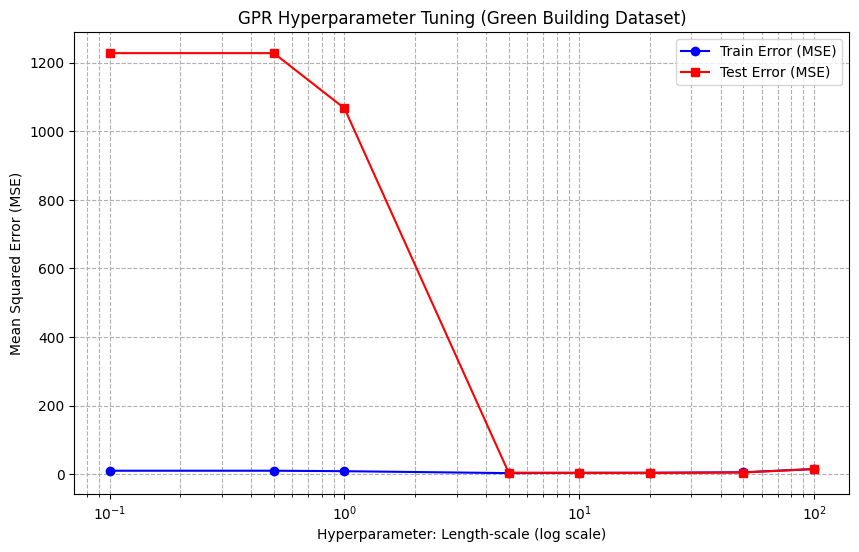

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_squared_error
import kagglehub

# 1. Load the green building dataset
kagglepath_green = "programmer3/green-building-multi-source-environment-dataset"
path_green = kagglehub.dataset_download(kagglepath_green)
print("Path to dataset files:", path_green)
df_green = pd.read_csv(path_green + "/green_building_dataset.csv")

# 2. Separate features (X) and target (y)
# We drop the two predicted output columns to get our input features
X_green = df_green.drop(columns=['predicted_energy_demand', 'predicted_comfort_index'])
y_green = df_green['predicted_energy_demand']

# 3. Split data into Train (80%) and Test (20%) sets using new variable names
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_green, y_green, test_size=0.2, random_state=42
)

# 4. Standardize the new features
scaler_g = StandardScaler()
X_train_g_scaled = scaler_g.fit_transform(X_train_g)
X_test_g_scaled = scaler_g.transform(X_test_g)

# 5. Define the range of length-scale values to test
length_scales = [0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0]

train_errors = []
test_errors = []

# 6. Loop through each length-scale value
for ls in length_scales:
    # Use a completely fresh kernel for each iteration
    new_kernel = RBF(length_scale=ls, length_scale_bounds='fixed')

    # Initialize a FRESH GPR model to avoid conflicting with older models
    gpr_green = GaussianProcessRegressor(kernel=new_kernel, alpha=0.1, random_state=42)
    gpr_green.fit(X_train_g_scaled, y_train_g)

    # Calculate Train Error (MSE)
    y_train_pred = gpr_green.predict(X_train_g_scaled)
    train_mse = mean_squared_error(y_train_g, y_train_pred)
    train_errors.append(train_mse)

    # Calculate Test Error (MSE)
    y_test_pred = gpr_green.predict(X_test_g_scaled)
    test_mse = mean_squared_error(y_test_g, y_test_pred)
    test_errors.append(test_mse)

# 7. Plotting the Tuning Curve
plt.figure(figsize=(10, 6))
plt.plot(length_scales, train_errors, label='Train Error (MSE)', marker='o', color='blue')
plt.plot(length_scales, test_errors, label='Test Error (MSE)', marker='s', color='red')
plt.xscale('log')
plt.xlabel('Hyperparameter: Length-scale (log scale)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('GPR Hyperparameter Tuning (Green Building Dataset)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### Hyperparameter Tuning Discussion

The generated plot in `image_91054a.png` clearly demonstrates the impact of the RBF kernel's **Length-scale ($l$)** on the Gaussian Process Regression (GPR) model's performance:

1. **Overfitting Region ($l \le 1.0$):**
   When the length-scale is small ($10^{-1}$ to $10^{0}$), the model assumes data points must be extremely close to share any correlation. This causes the functions to fluctuate rapidly. Consequently, the **Train Error (blue)** is near zero, but the **Test Error (red) is exceptionally high ($\approx 1200$)**, indicating severe **overfitting**.

2. **Optimal Hyperparameter Region ($5.0 \le l \le 20.0$):**
   As the length-scale increases toward $5.0$, the Test Error drops drastically and aligns perfectly with the Train Error, reaching a global minimum near zero. This is the **sweet spot (Optimal Region)** where the model generalizes perfectly to unseen data without losing accuracy.

3. **Underfitting Region ($l \ge 50.0$):**
   When the length-scale is increased too far ($10^2$), both the training and testing errors start creeping upward together. The functions become overly smooth, losing their ability to capture the underlying non-linear trends of the green building environment, leading to **underfitting**.

**Conclusion:**
The optimal length-scale for predicting `predicted_energy_demand` lies around $l = 5.0$ to $10.0$. At this point, the GPR model achieves its best generalization capability.